# Multimodal Cancer Classification Challenge 2026 — v11

**v10 scored 0.5846 LB vs 0.836 OOF — a 0.25 gap caused by overfit to train patients.**
v11 strategy: **simpler is better.** Strip every regularizer that was compressing predictions toward 0.5, add seed diversity, and add a full-data model so test patients see *some* coverage.

Changes vs v10:
- **Backbone**: EfficientNet-B0 → **ResNet-18** (22 M total params, less capacity to memorize patient idiosyncrasies, ~1.5× faster).
- **Removed**: SWA, label smoothing, gating fusion, RandomErasing, aggressive affine.
- **Lighter mixup** (α=0.1 instead of 0.2).
- **Kept**: RAM cache, patient-balanced sampler, D4 augmentation, paired-modality augmentation, OneCycleLR, AMP, 8-way D4 TTA, pos_weight, grad clip.
- **Added seed diversity**: 2 seeds × 3 folds = 6 fold-models, all of which are kept (no AUC gating needed; without SWA every model is trained the same way).
- **Added full-data model**: one extra model trained on all 12 patients for `median(best_epoch)` epochs across the CV folds — this is the model that sees the most signal.
- **Ensemble**: 6 fold-models + 1 full-data model = 7 checkpoints, each TTA-averaged.

Runtime budget (single T4):
- Cache: ~40 min (one-time)
- Training: 6 fold-models × ~15 min + 1 full-data × ~20 min ≈ 110 min
- TTA prediction: ~30 min
- **Total ≈ 3 h**.

Settings:
- Accelerator = **GPU T4 x2** (only GPU 0 is used; second stays idle).
- Internet = **On**.
- Persistence = **Files only**.

In [1]:
import os
os.environ["PYTHONUNBUFFERED"] = "1"

import re, io, json, time, random, glob, functools, gc
from pathlib import Path

# Always-flushed prints so Kaggle commit logs stay live.
print = functools.partial(print, flush=True)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader, Sampler
from torchvision import models
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold
from PIL import Image
import matplotlib.pyplot as plt

print("torch:", torch.__version__, "cuda:", torch.cuda.is_available(),
      "n_gpu:", torch.cuda.device_count())
!nvidia-smi -L

torch: 2.10.0+cu128 cuda: True n_gpu: 2
GPU 0: Tesla T4 (UUID: GPU-00bb8865-74ad-c3c5-9bcc-e3c40007268d)
GPU 1: Tesla T4 (UUID: GPU-0686a592-248f-c8c3-751b-97b517787d05)


In [2]:
DATA_ROOT = Path("/kaggle/input/datasets/rafaelproena/a3-adl")
assert (DATA_ROOT / "train.csv").exists(), f"train.csv not at {DATA_ROOT}"
print("DATA_ROOT =", DATA_ROOT)

OUT_DIR = Path("/kaggle/working/runs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# CV
N_SPLITS    = 3
BASE_SEED   = 1
SEEDS       = [1, 2]                # train 2 models per fold for diversity

# Optimization
EPOCHS      = 10
PATIENCE    = 5
BATCH_SIZE  = 128
LR          = 3e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP   = 1.0

# Regularization (deliberately light)
MIXUP_ALPHA  = 0.1                  # halved from v10
LABEL_SMOOTH = 0.0                  # disabled — was compressing predictions
DROPOUT      = 0.3

# Model
BACKBONE     = "resnet18"
PRETRAINED   = True

# Sampler
NUM_WORKERS = 2
PATIENTS_PER_BATCH = 4              # 4 patients × 32 cells/patient = 128 batch

# Full-data model: trained on every train patient. Epoch count is decided after CV.
TRAIN_FULL_DATA_MODEL = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if torch.cuda.is_available():
    torch.cuda.set_device(0)

BF_MEAN, BF_STD = 0.504, 0.216
FL_MEAN, FL_STD = 0.100, 0.144

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

seed_everything(BASE_SEED)

DATA_ROOT = /kaggle/input/datasets/rafaelproena/a3-adl


In [3]:
PAT_RE = re.compile(r"^pat_(\d+)_image_\d+\.jpg$")

def parse_patient_id(filename):
    m = PAT_RE.match(Path(filename).name)
    return int(m.group(1)) if m else None

def load_train_df(path):
    df = pd.read_csv(path); df.columns = [c.strip() for c in df.columns]
    df["patient_id"] = df["Name"].map(parse_patient_id).astype(int)
    return df

def load_test_df(path):
    df = pd.read_csv(path); df.columns = [c.strip() for c in df.columns]
    return df

def cache_split(names, bf_dir, fl_dir, label=""):
    bf_dir, fl_dir = Path(bf_dir), Path(fl_dir)
    bf, fl = {}, {}
    t0 = time.time()
    for i, n in enumerate(names):
        with open(bf_dir / n, "rb") as f: bf[n] = f.read()
        with open(fl_dir / n, "rb") as f: fl[n] = f.read()
        if (i + 1) % 20000 == 0:
            print(f"  [{label}] cached {i+1}/{len(names)} in {time.time()-t0:.1f}s")
    print(f"  [{label}] cached {len(names)} in {time.time()-t0:.1f}s")
    return bf, fl

class CachedCellDataset(Dataset):
    def __init__(self, df, bf_cache, fl_cache, bf_tf, fl_tf, paired_tf=None):
        self.df = df.reset_index(drop=True)
        self.bf_cache = bf_cache; self.fl_cache = fl_cache
        self.bf_tf = bf_tf; self.fl_tf = fl_tf
        self.paired_tf = paired_tf

    def __len__(self): return len(self.df)

    @staticmethod
    def _decode(buf):
        return Image.open(io.BytesIO(buf)).convert("L")

    def __getitem__(self, idx):
        row = self.df.iloc[idx]; name = row["Name"]
        bf = self.bf_tf(self._decode(self.bf_cache[name]))
        fl = self.fl_tf(self._decode(self.fl_cache[name]))
        if self.paired_tf is not None:
            bf, fl = self.paired_tf(bf, fl)
        label = int(row["Diagnosis"]) if "Diagnosis" in row else -1
        return {"bf": bf, "fl": fl, "label": label, "name": name}

In [4]:
def stratified_patient_kfold(df, n_splits=3, seed=1):
    skgf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    y = df["Diagnosis"].to_numpy(); groups = df["patient_id"].to_numpy()
    splits = list(skgf.split(df, y=y, groups=groups))
    for f, (_, va) in enumerate(splits):
        if len(np.unique(y[va])) < 2:
            raise ValueError(f"Fold {f} has only one class — try a different seed.")
    return splits

def summarize_split(df, tr, va):
    trd, vad = df.iloc[tr], df.iloc[va]
    return (f"train: {len(tr):>6} cells, {trd['patient_id'].nunique():>2}p, "
            f"pos {trd['Diagnosis'].mean():.3f} | "
            f"val: {len(va):>6} cells, {vad['patient_id'].nunique():>2}p, "
            f"pos {vad['Diagnosis'].mean():.3f} | "
            f"val pats: {sorted(vad['patient_id'].unique().tolist())}")

class PatientBalancedSampler(Sampler):
    """Each batch contains cells from `patients_per_batch` distinct patients,
    in roughly equal proportions. Reduces patient-specific overfit."""
    def __init__(self, df, batch_size, patients_per_batch=4, seed=0):
        assert batch_size % patients_per_batch == 0
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.per_pat = batch_size // patients_per_batch
        self.patients_per_batch = patients_per_batch
        self.rng = np.random.default_rng(seed)
        self.by_pat = {p: np.array(g.index.tolist())
                       for p, g in self.df.groupby("patient_id")}
        self.patients = list(self.by_pat.keys())
        self.epoch_len = len(self.df) // batch_size * batch_size

    def __len__(self): return self.epoch_len

    def __iter__(self):
        out = []
        for _ in range(self.epoch_len // self.batch_size):
            pats = self.rng.choice(self.patients,
                                   size=min(self.patients_per_batch, len(self.patients)),
                                   replace=False)
            for p in pats:
                idxs = self.by_pat[p]
                out.extend(self.rng.choice(idxs, size=self.per_pat,
                                           replace=len(idxs) < self.per_pat).tolist())
        return iter(out)

In [5]:
def _to_tensor_norm(mean, std):
    def fn(img):
        t = TF.to_tensor(img)
        return TF.normalize(t, [mean], [std])
    return fn

to_tensor_bf = _to_tensor_norm(BF_MEAN, BF_STD)
to_tensor_fl = _to_tensor_norm(FL_MEAN, FL_STD)

class PairedGeoAug:
    """Same geometric transform on BF and FL: D4 + mild rotation. No shift/erase."""
    def __init__(self, p_hflip=0.5, p_vflip=0.5, rot90=True, max_rot=10.0):
        self.p_hflip = p_hflip; self.p_vflip = p_vflip
        self.rot90 = rot90; self.max_rot = max_rot

    def __call__(self, bf, fl):
        if self.rot90:
            k = random.randint(0, 3)
            if k:
                bf = torch.rot90(bf, k, dims=(-2, -1))
                fl = torch.rot90(fl, k, dims=(-2, -1))
        if random.random() < self.p_hflip: bf, fl = TF.hflip(bf), TF.hflip(fl)
        if random.random() < self.p_vflip: bf, fl = TF.vflip(bf), TF.vflip(fl)
        if self.max_rot > 0:
            a = random.uniform(-self.max_rot, self.max_rot)
            bf, fl = TF.rotate(bf, a), TF.rotate(fl, a)
        return bf, fl

def train_modality_transform(modality):
    norm = to_tensor_bf if modality == "bf" else to_tensor_fl
    return T.Compose([T.ColorJitter(brightness=0.2, contrast=0.2), norm])

def eval_modality_transform(modality):
    return to_tensor_bf if modality == "bf" else to_tensor_fl

In [6]:
def _make_resnet18_branch(pretrained=True):
    weights = "DEFAULT" if pretrained else None
    net = models.resnet18(weights=weights)
    w = net.conv1.weight.data
    new_conv = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    if pretrained:
        new_conv.weight.data = w.mean(dim=1, keepdim=True)
    net.conv1 = new_conv
    fd = net.fc.in_features; net.fc = nn.Identity()
    return net, fd  # 512

class MultimodalClassifier(nn.Module):
    """Two ResNet-18 branches + simple concat fusion head. No gating."""
    def __init__(self, pretrained=True, dropout=DROPOUT):
        super().__init__()
        self.bf_branch, fd = _make_resnet18_branch(pretrained)
        self.fl_branch, _  = _make_resnet18_branch(pretrained)
        self.head = nn.Sequential(
            nn.Linear(fd * 2, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, 1),
        )

    def forward(self, bf, fl):
        feat = torch.cat([self.bf_branch(bf), self.fl_branch(fl)], dim=1)
        return self.head(feat).squeeze(-1)

with torch.no_grad():
    _m = MultimodalClassifier(pretrained=False).cpu()
    _x = torch.zeros(2, 1, 128, 128)
    print("Output shape:", _m(_x, _x).shape,
          "  params:", sum(p.numel() for p in _m.parameters()) // 1_000_000, "M")
    del _m, _x

Output shape: torch.Size([2])   params: 22 M


In [7]:
df_train = load_train_df(DATA_ROOT / "train.csv")
df_test  = load_test_df(DATA_ROOT / "sampleSubmission.csv")
print(f"Train: {len(df_train)} cells, {df_train['patient_id'].nunique()} patients, "
      f"pos rate {df_train['Diagnosis'].mean():.4f}")
print(f"Test:  {len(df_test)} cells")

print("\n--- Caching JPEG bytes into RAM ---")
bf_train_cache, fl_train_cache = cache_split(
    df_train["Name"].tolist(),
    DATA_ROOT / "BF" / "train", DATA_ROOT / "FL" / "train", label="train")
bf_test_cache, fl_test_cache = cache_split(
    df_test["Name"].tolist(),
    DATA_ROOT / "BF" / "test", DATA_ROOT / "FL" / "test", label="test")
approx_mb = (sum(len(b) for b in bf_train_cache.values()) +
             sum(len(b) for b in fl_train_cache.values()) +
             sum(len(b) for b in bf_test_cache.values()) +
             sum(len(b) for b in fl_test_cache.values())) / (1024 * 1024)
print(f"\nApprox RAM used by JPEG cache: {approx_mb:.0f} MB")

Train: 114302 cells, 12 patients, pos rate 0.3876
Test:  59040 cells

--- Caching JPEG bytes into RAM ---
  [train] cached 20000/114302 in 289.2s
  [train] cached 40000/114302 in 572.3s
  [train] cached 60000/114302 in 881.5s
  [train] cached 80000/114302 in 1187.0s
  [train] cached 100000/114302 in 1523.7s
  [train] cached 114302 in 1756.4s
  [test] cached 20000/59040 in 368.1s
  [test] cached 40000/59040 in 724.2s
  [test] cached 59040 in 1026.1s

Approx RAM used by JPEG cache: 755 MB


In [8]:
def mixup_batch(bf, fl, y, alpha=0.1):
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(bf.size(0), device=bf.device)
    return (lam * bf + (1 - lam) * bf[idx],
            lam * fl + (1 - lam) * fl[idx],
            lam * y  + (1 - lam) * y[idx])

def run_epoch(model, loader, optimizer, scaler, criterion, train,
              mixup_alpha=0.0, grad_clip=0.0, sched=None, log_every=0):
    model.train(train)
    losses, hard_ys, ps = [], [], []
    t_last = time.time()
    for i, batch in enumerate(loader):
        bf = batch["bf"].to(DEVICE, non_blocking=True)
        fl = batch["fl"].to(DEVICE, non_blocking=True)
        y  = batch["label"].float().to(DEVICE, non_blocking=True)
        hard_ys.append(batch["label"].numpy())

        if train and mixup_alpha > 0:
            bf, fl, y = mixup_batch(bf, fl, y, mixup_alpha)

        with torch.amp.autocast("cuda", enabled=scaler is not None):
            logits = model(bf, fl)
            loss = criterion(logits, y)

        if train:
            optimizer.zero_grad(set_to_none=True)
            if scaler is not None:
                scaler.scale(loss).backward()
                if grad_clip > 0:
                    scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                old_scale = scaler.get_scale()
                scaler.step(optimizer); scaler.update()
                if sched is not None and scaler.get_scale() >= old_scale:
                    sched.step()
            else:
                loss.backward()
                if grad_clip > 0: nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()
                if sched is not None: sched.step()

        losses.append(loss.item())
        ps.append(torch.sigmoid(logits).detach().float().cpu().numpy())

        if log_every and (i + 1) % log_every == 0:
            dt = time.time() - t_last; t_last = time.time()
            print(f"    step {i+1}/{len(loader)} | {dt:.1f}s | loss {float(np.mean(losses[-log_every:])):.4f}")

    hard_ys = np.concatenate(hard_ys); ps = np.concatenate(ps)
    auc = roc_auc_score(hard_ys, ps) if len(np.unique(hard_ys)) > 1 else float("nan")
    return float(np.mean(losses)), auc, hard_ys, ps


def train_one_model(train_df, val_df, ckpt_path, oof_path, hist_path,
                   epochs, seed, sampler_kind="patient", track_oof=True):
    """Train one model on `train_df`, validate on `val_df` (can be None).
    Returns the best validation AUC reached and the epoch at which it occurred.
    """
    seed_everything(seed)

    train_ds = CachedCellDataset(train_df, bf_train_cache, fl_train_cache,
                                 train_modality_transform("bf"),
                                 train_modality_transform("fl"),
                                 paired_tf=PairedGeoAug())
    if sampler_kind == "patient":
        sampler = PatientBalancedSampler(train_df, batch_size=BATCH_SIZE,
                                         patients_per_batch=PATIENTS_PER_BATCH,
                                         seed=seed)
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                                  num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    else:
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                                  num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)

    val_loader = None
    if val_df is not None:
        val_ds = CachedCellDataset(val_df, bf_train_cache, fl_train_cache,
                                   eval_modality_transform("bf"),
                                   eval_modality_transform("fl"))
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE * 2, shuffle=False,
                                num_workers=NUM_WORKERS, pin_memory=True)

    model = MultimodalClassifier(pretrained=PRETRAINED, dropout=DROPOUT).to(DEVICE)
    pos = (train_df["Diagnosis"] == 1).sum()
    neg = (train_df["Diagnosis"] == 0).sum()
    pos_weight = torch.tensor(neg / max(pos, 1), device=DEVICE)
    print(f"  pos_weight={pos_weight.item():.3f}  seed={seed}  epochs={epochs}")
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=LR,
        steps_per_epoch=len(train_loader), epochs=epochs, pct_start=0.1)
    scaler = torch.amp.GradScaler("cuda") if DEVICE == "cuda" else None

    history, best_auc, best_ep, no_improve = [], -1.0, 0, 0
    for ep in range(epochs):
        t0 = time.time()
        tr_loss, tr_auc, _, _ = run_epoch(
            model, train_loader, optimizer, scaler, criterion, True,
            mixup_alpha=MIXUP_ALPHA, grad_clip=GRAD_CLIP, sched=sched, log_every=200)
        va_loss = va_auc = float("nan"); vy = vp = None
        if val_loader is not None:
            with torch.no_grad():
                va_loss, va_auc, vy, vp = run_epoch(
                    model, val_loader, None, None, criterion, False)
        dt = time.time() - t0
        print(f"  ep {ep:>2d} | tr_loss {tr_loss:.4f} tr_auc {tr_auc:.4f} "
              f"| va_loss {va_loss:.4f} va_auc {va_auc:.4f} | {dt:.1f}s")
        history.append({"epoch": ep, "tr_loss": tr_loss, "tr_auc": tr_auc,
                        "va_loss": va_loss, "va_auc": va_auc, "time": dt})

        save_now = False
        if val_loader is not None:
            if va_auc > best_auc:
                best_auc, best_ep, no_improve = va_auc, ep, 0
                save_now = True
            else:
                no_improve += 1
        else:
            # No val set (full-data model): save every epoch, keep the last.
            save_now = True; best_ep = ep

        if save_now:
            torch.save({"model": model.state_dict(), "epoch": ep,
                        "val_auc": va_auc if val_loader is not None else None,
                        "args": {"backbone": BACKBONE, "dropout": DROPOUT}}, ckpt_path)
            if track_oof and val_loader is not None:
                pd.DataFrame({"Name": val_df["Name"].values,
                              "patient_id": val_df["patient_id"].values,
                              "y_true": vy, "y_pred": vp}).to_csv(oof_path, index=False)

        if val_loader is not None and no_improve >= PATIENCE:
            print(f"  Early stopping at epoch {ep}"); break

    with open(hist_path, "w") as f:
        json.dump({"history": history, "best_auc": best_auc, "best_ep": best_ep}, f, indent=2)

    del model, optimizer, sched, scaler, train_loader
    if val_loader is not None: del val_loader
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return best_auc, best_ep

In [9]:
splits = stratified_patient_kfold(df_train, N_SPLITS, seed=BASE_SEED)
print(f"CV folds={len(splits)}  seeds={SEEDS}  backbone={BACKBONE}\n")

all_results = []   # list of dicts with fold, seed, best_auc, best_ep
for fold, (tr, va) in enumerate(splits):
    print(f"=== FOLD {fold} ===")
    print("  " + summarize_split(df_train, tr, va))
    train_df = df_train.iloc[tr].reset_index(drop=True)
    val_df   = df_train.iloc[va].reset_index(drop=True)

    for seed in SEEDS:
        tag = f"fold{fold}_seed{seed}"
        print(f"  --- {tag} ---")
        ckpt = OUT_DIR / f"{tag}_best.pt"
        oof  = OUT_DIR / f"{tag}_oof.csv"
        hist = OUT_DIR / f"{tag}_history.json"
        best_auc, best_ep = train_one_model(
            train_df, val_df, ckpt, oof, hist,
            epochs=EPOCHS, seed=seed)
        all_results.append({"fold": fold, "seed": seed,
                            "best_auc": best_auc, "best_ep": best_ep})
        print(f"  {tag}: best AUC = {best_auc:.4f} at ep {best_ep}\n")

df_results = pd.DataFrame(all_results)
print("\n=== CV summary ===")
print(df_results.to_string(index=False))
print(f"Mean best AUC: {df_results['best_auc'].mean():.4f}  std {df_results['best_auc'].std():.4f}")
print(f"Median best epoch: {int(df_results['best_ep'].median())}")

CV folds=3  seeds=[1, 2]  backbone=resnet18

=== FOLD 0 ===
  train:  74302 cells,  8p, pos 0.327 | val:  40000 cells,  4p, pos 0.500 | val pats: [3, 9, 14, 18]
  --- fold0_seed1 ---
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 225MB/s]


  pos_weight=2.057  seed=1  epochs=10
    step 200/580 | 45.7s | loss 0.8096
    step 400/580 | 40.7s | loss 0.6911
  ep  0 | tr_loss 0.7243 tr_auc 0.6750 | va_loss 0.8203 va_auc 0.8202 | 154.8s
    step 200/580 | 40.9s | loss 0.6372
    step 400/580 | 41.2s | loss 0.6401
  ep  1 | tr_loss 0.6258 tr_auc 0.7027 | va_loss 0.8434 va_auc 0.7747 | 152.1s
    step 200/580 | 42.5s | loss 0.5646
    step 400/580 | 40.9s | loss 0.5622
  ep  2 | tr_loss 0.5652 tr_auc 0.7113 | va_loss 0.9158 va_auc 0.7413 | 150.7s
    step 200/580 | 41.2s | loss 0.5347
    step 400/580 | 41.1s | loss 0.5194
  ep  3 | tr_loss 0.5201 tr_auc 0.7356 | va_loss 0.8833 va_auc 0.7763 | 150.6s
    step 200/580 | 41.6s | loss 0.4868
    step 400/580 | 40.7s | loss 0.4907
  ep  4 | tr_loss 0.4807 tr_auc 0.7461 | va_loss 1.0487 va_auc 0.6694 | 151.5s
    step 200/580 | 41.3s | loss 0.4202
    step 400/580 | 40.5s | loss 0.4464
  ep  5 | tr_loss 0.4133 tr_auc 0.7423 | va_loss 1.0803 va_auc 0.6998 | 149.6s
  Early stopping at 

In [10]:
# Train one model on ALL 12 train patients (no val), for the median best epoch
# observed during CV. This model sees every patient — its predictions on test
# patients will be different from any CV-fold model and adds ensemble diversity.
if TRAIN_FULL_DATA_MODEL:
    median_ep = int(df_results['best_ep'].median()) + 1   # +1 because index → count
    full_epochs = max(median_ep, 5)
    print(f"\n=== FULL-DATA MODEL (epochs={full_epochs}) ===")
    ckpt = OUT_DIR / "fulldata_best.pt"
    hist = OUT_DIR / "fulldata_history.json"
    train_one_model(df_train, None, ckpt, None, hist,
                    epochs=full_epochs, seed=BASE_SEED + 100,
                    sampler_kind="patient", track_oof=False)
    print("  full-data model saved.")
else:
    print("(skipping full-data model)")


=== FULL-DATA MODEL (epochs=6) ===
  pos_weight=1.580  seed=101  epochs=6
    step 200/892 | 42.0s | loss 0.7519
    step 400/892 | 41.3s | loss 0.6843
    step 600/892 | 41.9s | loss 0.6450
    step 800/892 | 42.0s | loss 0.6217
  ep  0 | tr_loss 0.6724 tr_auc 0.6689 | va_loss nan va_auc nan | 186.1s
    step 200/892 | 42.6s | loss 0.5858
    step 400/892 | 42.3s | loss 0.5733
    step 600/892 | 42.3s | loss 0.5806
    step 800/892 | 41.5s | loss 0.5684
  ep  1 | tr_loss 0.5820 tr_auc 0.7044 | va_loss nan va_auc nan | 187.9s
    step 200/892 | 42.4s | loss 0.5336
    step 400/892 | 41.5s | loss 0.5238
    step 600/892 | 41.4s | loss 0.4932
    step 800/892 | 41.4s | loss 0.5183
  ep  2 | tr_loss 0.5161 tr_auc 0.7325 | va_loss nan va_auc nan | 185.6s
    step 200/892 | 41.6s | loss 0.4828
    step 400/892 | 41.3s | loss 0.4628
    step 600/892 | 41.0s | loss 0.4180
    step 800/892 | 41.0s | loss 0.4321
  ep  3 | tr_loss 0.4472 tr_auc 0.7602 | va_loss nan va_auc nan | 184.0s
    step 

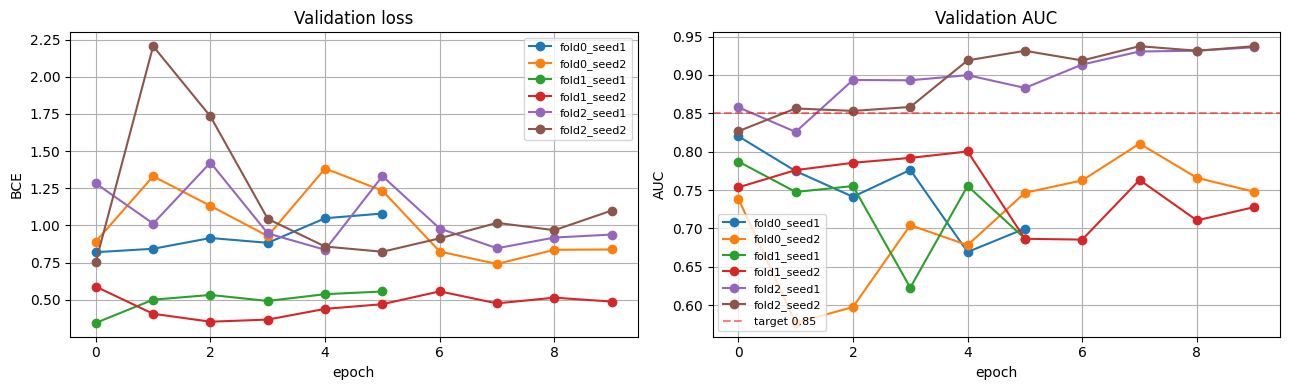

In [11]:
# Validation AUC vs epoch for every CV model.
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for hp in sorted(glob.glob(str(OUT_DIR / "fold*_history.json"))):
    h = json.load(open(hp))["history"]
    label = Path(hp).stem.replace("_history", "")
    ax[0].plot([e["epoch"] for e in h], [e["va_loss"] for e in h], marker="o", label=label)
    ax[1].plot([e["epoch"] for e in h], [e["va_auc"]  for e in h], marker="o", label=label)
ax[0].set(title="Validation loss", xlabel="epoch", ylabel="BCE")
ax[1].set(title="Validation AUC",  xlabel="epoch", ylabel="AUC")
ax[1].axhline(0.85, color="red", linestyle="--", alpha=0.5, label="target 0.85")
for a in ax: a.legend(fontsize=8); a.grid(True)
plt.tight_layout()
plt.savefig("/kaggle/working/learning_curves.png", dpi=120, bbox_inches="tight")
plt.show()

In [12]:
# Combined OOF across CV models (average predictions per cell within each fold).
fold_oofs = []
for fold in range(N_SPLITS):
    seed_oofs = []
    for seed in SEEDS:
        p = OUT_DIR / f"fold{fold}_seed{seed}_oof.csv"
        if p.exists(): seed_oofs.append(pd.read_csv(p))
    if not seed_oofs: continue
    base = seed_oofs[0][["Name", "patient_id", "y_true"]].copy()
    base["y_pred"] = np.mean([d["y_pred"].values for d in seed_oofs], axis=0)
    fold_oofs.append(base)
if fold_oofs:
    oof = pd.concat(fold_oofs, ignore_index=True)
    cell_auc = roc_auc_score(oof["y_true"], oof["y_pred"])
    pp = oof.groupby("patient_id").agg(
        mean_pred=("y_pred", "mean"), median_pred=("y_pred", "median"),
        label=("y_true", "first")).sort_values("mean_pred")
    pat_auc = roc_auc_score(pp["label"], pp["mean_pred"])
    print(f"=== OOF (seed-averaged) ===")
    print(pp.to_string())
    print(f"\ncell-level OOF AUC: {cell_auc:.4f}    patient-level AUC: {pat_auc:.4f}")
else:
    print("No OOF files found.")

=== OOF (seed-averaged) ===
            mean_pred  median_pred  label
patient_id                               
7            0.040978     0.021548      0
10           0.083284     0.026879      0
13           0.122809     0.070683      0
11           0.148193     0.068417      0
15           0.259732     0.138598      0
14           0.299353     0.229608      0
9            0.446396     0.436855      0
17           0.450215     0.448216      1
5            0.465325     0.466931      1
16           0.541210     0.566518      1
18           0.714043     0.732807      1
3            0.753792     0.803798      1

cell-level OOF AUC: 0.8668    patient-level AUC: 1.0000


In [13]:
def _d4(bf, fl):
    for k in range(4):
        bfr = torch.rot90(bf, k, dims=(-2, -1))
        flr = torch.rot90(fl, k, dims=(-2, -1))
        yield bfr, flr
        yield TF.hflip(bfr), TF.hflip(flr)

def load_model_from_ckpt(ckpt_path):
    state = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    args = state.get("args", {})
    dropout = float(args.get("dropout", DROPOUT))
    model = MultimodalClassifier(pretrained=False, dropout=dropout).to(DEVICE)
    model.load_state_dict(state["model"]); model.eval()
    return model

def predict_one_ckpt(ckpt_path, loader, tta=True):
    model = load_model_from_ckpt(ckpt_path)
    preds = []
    n_aug = 8 if tta else 1
    with torch.no_grad():
        for batch in loader:
            bf = batch["bf"].to(DEVICE, non_blocking=True)
            fl = batch["fl"].to(DEVICE, non_blocking=True)
            p = None
            for bf_t, fl_t in (_d4(bf, fl) if tta else [(bf, fl)]):
                with torch.amp.autocast("cuda", enabled=DEVICE == "cuda"):
                    pi = torch.sigmoid(model(bf_t, fl_t)).float()
                p = pi if p is None else p + pi
            preds.append((p / n_aug).cpu().numpy())
    del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return np.concatenate(preds)

test_ds = CachedCellDataset(df_test, bf_test_cache, fl_test_cache,
                            eval_modality_transform("bf"),
                            eval_modality_transform("fl"))
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

# Ensemble: every CV model (3 folds × 2 seeds = 6) plus the full-data model.
ckpts = sorted(glob.glob(str(OUT_DIR / "fold*_best.pt")))
if TRAIN_FULL_DATA_MODEL and (OUT_DIR / "fulldata_best.pt").exists():
    ckpts.append(str(OUT_DIR / "fulldata_best.pt"))
print("Ensembling:")
for c in ckpts: print("  -", c)

all_preds = []
for c in ckpts:
    t0 = time.time()
    all_preds.append(predict_one_ckpt(c, test_loader, tta=True))
    print(f"  {Path(c).name} done in {time.time()-t0:.1f}s")

preds = np.mean(all_preds, axis=0)
sub = pd.DataFrame({"Name": df_test["Name"].values, "Diagnosis": preds})
sub.to_csv("/kaggle/working/submission.csv", index=False)
print(f"\nWrote submission.csv  (mean pred = {preds.mean():.3f}, "
      f"min {preds.min():.3f}, max {preds.max():.3f})")
print(sub.head())
!wc -l /kaggle/working/submission.csv

Ensembling:
  - /kaggle/working/runs/fold0_seed1_best.pt
  - /kaggle/working/runs/fold0_seed2_best.pt
  - /kaggle/working/runs/fold1_seed1_best.pt
  - /kaggle/working/runs/fold1_seed2_best.pt
  - /kaggle/working/runs/fold2_seed1_best.pt
  - /kaggle/working/runs/fold2_seed2_best.pt
  - /kaggle/working/runs/fulldata_best.pt
  fold0_seed1_best.pt done in 136.6s
  fold0_seed2_best.pt done in 135.5s
  fold1_seed1_best.pt done in 136.1s
  fold1_seed2_best.pt done in 136.3s
  fold2_seed1_best.pt done in 136.6s
  fold2_seed2_best.pt done in 136.6s
  fulldata_best.pt done in 136.5s

Wrote submission.csv  (mean pred = 0.396, min 0.002, max 0.981)
          Name  Diagnosis
0  image_1.jpg   0.570993
1  image_2.jpg   0.227700
2  image_3.jpg   0.763227
3  image_4.jpg   0.298628
4  image_5.jpg   0.121993
59041 /kaggle/working/submission.csv
